In [3]:
import pandas as pd 

data=pd.read_csv('../data/delivery.csv')
data.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,multiple_deliveries,Festival,City,"[""source""",City.1,Type_of_order.1,Time_Order_picked.1,Time_Orderd.1,ID.1,"Delivery_person_ID""]"
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,...,0,No,Urban,(min) 24,train,NaN,NaN,NaN,NaN,NaN
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,...,1,No,Metropolitian,(min) 33,train,NaN,NaN,NaN,NaN,NaN
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,...,1,No,Urban,(min) 26,train,NaN,NaN,NaN,NaN,NaN
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,...,1,No,Metropolitian,(min) 21,train,NaN,NaN,NaN,NaN,NaN
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,...,1,No,Metropolitian,(min) 30,train,NaN,NaN,NaN,NaN,NaN


In [2]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 56992 entries, 0 to 56991
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           56992 non-null  str    
 1   Delivery_person_ID           56992 non-null  str    
 2   Delivery_person_Age          56992 non-null  str    
 3   Delivery_person_Ratings      56992 non-null  str    
 4   Restaurant_latitude          56992 non-null  float64
 5   Restaurant_longitude         56992 non-null  float64
 6   Delivery_location_latitude   56992 non-null  float64
 7   Delivery_location_longitude  56992 non-null  float64
 8   Order_Date                   56992 non-null  str    
 9   Time_Orderd                  56992 non-null  str    
 10  Time_Order_picked            56992 non-null  str    
 11  Weatherconditions            56992 non-null  str    
 12  Road_traffic_density         56992 non-null  str    
 13  Vehicle_condition          

In [ ]:
data = data[~data.apply(lambda row: row.astype(str).str.contains("NaN").any(), axis=1)]


In [17]:
data["Delivery_location_latitude"]=data["Delivery_location_latitude"].astype(float)
data["Delivery_location_latitude"]=data["Delivery_location_latitude"].replace({'NaN':0})


In [18]:

# Clean string NaNs in Time_Orderd
# data['Time_Orderd'] = data['Time_Orderd'].astype(str).str.strip().replace({'NaN': float('nan'), 'nan': float('nan'), 'None': float('nan'), '': float('nan')})

# Convert both to datetime
data['Time_Orderd']        = pd.to_datetime(data['Time_Orderd'],        format='%H:%M:%S', errors='coerce')
data['Time_Order_picked']  = pd.to_datetime(data['Time_Order_picked'],  format='%H:%M:%S', errors='coerce')

# Compute prep duration in minutes
 
data['Preparation_Duration'] = (data['Time_Order_picked'] - data['Time_Orderd']).dt.total_seconds() / 60

# Handle negative values (midnight crossing e.g. 23:50 -> 00:05)
data.loc[data['Preparation_Duration'] < 0, 'Preparation_Duration'] += 1440


In [21]:
data.info()

<class 'pandas.DataFrame'>
Index: 51659 entries, 0 to 56991
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           51659 non-null  str           
 1   Delivery_person_ID           51659 non-null  str           
 2   Delivery_person_Age          51659 non-null  int64         
 3   Delivery_person_Ratings      51659 non-null  float64       
 4   Restaurant_latitude          51659 non-null  float64       
 5   Restaurant_longitude         51659 non-null  float64       
 6   Delivery_location_latitude   51659 non-null  float64       
 7   Delivery_location_longitude  51659 non-null  float64       
 8   Order_Date                   51659 non-null  str           
 9   Time_Orderd                  51659 non-null  datetime64[us]
 10  Time_Order_picked            51659 non-null  datetime64[us]
 11  Weatherconditions            51659 non-null  str         

In [13]:
data["Delivery_person_Ratings"]

0        4.9
1        4.5
2        4.4
3        4.7
4        4.6
        ... 
56986    4.7
56987    4.6
56988    4.9
56990    4.7
56991    5.0
Name: Delivery_person_Ratings, Length: 51659, dtype: float64

In [ ]:
# data = data.dropna(subset=["Time_taken(min)"])
data["Time_taken(min)"] = data["Time_taken(min)"].astype(int)

In [ ]:
["Type_of_vehicle","Road_traffic_density","Weatherconditions"]

In [31]:
data["Time_taken(min)"]

0        24
1        33
2        26
3        21
4        30
         ..
45588    32
45589    36
45590    16
45591    26
45592    36
Name: Time_taken(min), Length: 41368, dtype: int64

In [10]:
data["Delivery_person_Ratings"]=data["Delivery_person_Ratings"].astype(float)


In [ ]:

# Clean string NaNs in Time_Orderd
# data['Time_Orderd'] = data['Time_Orderd'].astype(str).str.strip().replace({'NaN': float('nan'), 'nan': float('nan'), 'None': float('nan'), '': float('nan')})

# Convert both to datetime
data['Time_Orderd']        = pd.to_datetime(data['Time_Orderd'],        format='%H:%M:%S', errors='coerce')
data['Time_Order_picked']  = pd.to_datetime(data['Time_Order_picked'],  format='%H:%M:%S', errors='coerce')

# Compute prep duration in minutes
 
data['Preparation_Duration'] = (data['Time_Order_picked'] - data['Time_Orderd']).dt.total_seconds() / 60

# Handle negative values (midnight crossing e.g. 23:50 -> 00:05)
data.loc[data['Preparation_Duration'] < 0, 'Preparation_Duration'] += 1440


In [23]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

to_drop=["source","City","Order_Date","Type_of_order","Time_Order_picked","Time_Orderd","ID","Delivery_person_ID"]
ohe_categories=["Weatherconditions","Type_of_vehicle"]

ohe = OneHotEncoder(sparse_output=False)
encoded=ohe.fit_transform(data[ohe_categories])
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(ohe_categories))
data = data.drop(columns=ohe_categories)
data = pd.concat([data, encoded_df], axis=1) 





In [32]:
ohe_categories=["Festival","Road_traffic_density"]
encoded=ohe.fit_transform(data[ohe_categories])
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(ohe_categories))
data = data.drop(columns=ohe_categories)
data = pd.concat([data, encoded_df], axis=1) 

In [24]:

oe=OrdinalEncoder()
data["Road_traffic_density"] = oe.fit_transform(
    data[["Road_traffic_density"]]
)

In [33]:
data["Festival"].value_counts()

KeyError: 'Festival'

In [30]:

# data["Vehicle_condition"]=data["Vehicle_condition"].astype(int)
data["Vehicle_condition"]=data["Vehicle_condition"].replace({'NaN':4})


In [20]:
ohe = OneHotEncoder(sparse_output=False)
encoded=ohe.fit_transform(data[["Festival"]])
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(["Festival"]))
data = data.drop(columns="Festival")
data = pd.concat([data, encoded_df], axis=1) 

In [ ]:
data["Time_taken(min)"] = data["Time_taken(min)"].str.replace("(min) ", "", regex=False)

In [38]:
data['["source"'] = data['["source"'].str.replace("(min) ", "", regex=False)

In [51]:
data.info()

<class 'pandas.DataFrame'>
Index: 56941 entries, 0 to 56462
Data columns (total 40 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   ID                                       51659 non-null  str           
 1   Delivery_person_ID                       51659 non-null  str           
 2   Delivery_person_Age                      51659 non-null  float64       
 3   Delivery_person_Ratings                  51659 non-null  float64       
 4   Restaurant_latitude                      51659 non-null  float64       
 5   Restaurant_longitude                     51659 non-null  float64       
 6   Delivery_location_latitude               51659 non-null  float64       
 7   Delivery_location_longitude              51659 non-null  float64       
 8   Order_Date                               51659 non-null  str           
 9   Time_Orderd                              51659 non-null

In [ ]:
# data['["source"']=data['["source"'].replace({'NaN':data['["source"'].astype(int).median()})

data['["source"'] = data['Delevery'].fillna(0).astype(int).median()

In [55]:
data['["source"']

0        21.0
1        21.0
2        21.0
3        21.0
4        21.0
         ... 
56431    21.0
56447    21.0
56452    21.0
56459    21.0
56462    21.0
Name: ["source", Length: 56941, dtype: float64

In [ ]:
data["Delivery_person_Age"].value_counts()

Delivery_person_Ratings
4.8    8422
4.9    8417
4.7    8370
4.6    8144
5      4720
4.5    3896
4.2    1712
4.3    1694
4.1    1688
4.4    1616
4      1327
3.5     306
3.7     277
3.8     273
3.9     251
3.6     251
3.4      43
3.3      38
3.2      36
3.1      34
2.6      33
2.5      28
2.7      28
2.9      26
2.8      22
3         7
Name: count, dtype: int64

In [11]:
data["Festival"].value_counts()

Festival
No      50630
Yes      1029
Name: count, dtype: int64

In [12]:
data.info()


<class 'pandas.DataFrame'>
Index: 51659 entries, 0 to 56991
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           51659 non-null  str    
 1   Delivery_person_ID           51659 non-null  str    
 2   Delivery_person_Age          51659 non-null  int64  
 3   Delivery_person_Ratings      51659 non-null  float64
 4   Restaurant_latitude          51659 non-null  float64
 5   Restaurant_longitude         51659 non-null  float64
 6   Delivery_location_latitude   51659 non-null  float64
 7   Delivery_location_longitude  51659 non-null  float64
 8   Order_Date                   51659 non-null  str    
 9   Time_Orderd                  51659 non-null  str    
 10  Time_Order_picked            51659 non-null  str    
 11  Weatherconditions            51659 non-null  str    
 12  Road_traffic_density         51659 non-null  str    
 13  Vehicle_condition            516

In [53]:
print(data.isna().sum())

ID                                 0
Delivery_person_ID                 0
Delivery_person_Age                0
Delivery_person_Ratings            0
Restaurant_latitude                0
Restaurant_longitude               0
Delivery_location_latitude         0
Delivery_location_longitude        0
Order_Date                         0
Time_Orderd                        0
Time_Order_picked                  0
Weatherconditions                  0
Road_traffic_density               0
Vehicle_condition                  0
Type_of_order                      0
Type_of_vehicle                    0
multiple_deliveries                0
Festival                           0
City                               0
Time_taken(min)                11399
source                             0
dtype: int64


In [59]:

# data["Weatherconditions"].fillna(data["Weatherconditions"].mode()[0], inplace=True)

data["Weatherconditions"] = data["Weatherconditions"].replace({'conditions NaN':data["Weatherconditions"].mode()[0]})

In [ ]:
# data["multiple_deliveries"].value_counts()
data["multiple_deliveries"]=data["multiple_deliveries"].replace({'NaN':4}).astype(int)
# data["multiple_deliveries"].astype(int)

In [ ]:
data["Delivery_Time(min)"] = data["Time_taken(min)"].str.extract(r'(\d+)')
data["Delivery_Time(min)"].astype(str).str.strip().replace({'NaN': float('nan'), 'nan': float('nan'), 
              'NULL': float('nan'), 'None': float('nan'), 
              '': float('nan')})  
data["Delivery_Time(min)"].fillna(data["Delivery_Time(min)"].mean(), inplace=True)
data["Delivery_Time(min)"]

In [ ]:
data["Delivery_person_Ratings"] = (
    data["Delivery_person_Ratings"]
    .astype(str)
    .str.strip()
    .replace({'NaN': float('nan'), 'nan': float('nan'), 
              'NULL': float('nan'), 'None': float('nan'), 
              '': float('nan')})
)
data["Delivery_person_Ratings"] = pd.to_numeric(data["Delivery_person_Ratings"], errors='coerce')
median_rating = data["Delivery_person_Ratings"].median()
data["Delivery_person_Ratings"] = data["Delivery_person_Ratings"].fillna(median_rating)

data["Delivery_person_Ratings"] = data["Delivery_person_Ratings"].astype(float)



In [ ]:
data["Delivery_person_Ratings"].info()

In [ ]:
data["Delivery_person_Age"] = (
    data["Delivery_person_Age"]
    .astype(str)
    .str.strip()
    .replace({'NaN': float('nan'), 'nan': float('nan'), 
              'NULL': float('nan'), 'None': float('nan'), 
              '': float('nan')})
)
data["Delivery_person_Age"] = pd.to_numeric(data["Delivery_person_Age"], errors='coerce')
median_age = data["Delivery_person_Age"].median()
data["Delivery_person_Age"] = data["Delivery_person_Age"].fillna(median_age)

data["Delivery_person_Age"] = data["Delivery_person_Age"].astype(float)



In [ ]:
data["Order_Date"]=pd.to_datetime(data["Order_Date"])


C:\Users\HP\AppData\Local\Temp\ipykernel_11512\3801261332.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data["Order_Date"]=pd.to_datetime(data["Order_Date"])


In [ ]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

to_drop=["source","City","Festival","Type_of_order","Time_Order_picked","Time_Orderd","ID","Delivery_person_ID"]
ohe_categories=["Weatherconditions","Type_of_vehicle"]

ohe = OneHotEncoder(sparse_output=False)
encoded=ohe.fit_transform(data[ohe_categories])
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(ohe_categories))
data = data.drop(columns=ohe_categories)
data = pd.concat([data, encoded_df], axis=1) 


oe=OrdinalEncoder()
data["Road_traffic_density"]=oe.fit_transform(data["Road_traffic_density"])



In [ ]:
data

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Weatherconditions_conditions Fog,Weatherconditions_conditions NaN,Weatherconditions_conditions Sandstorms,Weatherconditions_conditions Stormy,Weatherconditions_conditions Sunny,Weatherconditions_conditions Windy,Type_of_vehicle_bicycle,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,1900-01-01 11:30:00,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,1900-01-01 19:45:00,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,1900-01-01 08:30:00,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,1900-01-01 18:00:00,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,1900-01-01 13:30:00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56987,0x6909,JAPRES01DEL01,35,4.6,26.905190,75.810753,27.015190,75.920753,2022-03-27,1900-01-01 21:35:00,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
56988,0x443b,JAPRES11DEL01,33,4.9,26.902940,75.793007,26.912940,75.803007,2022-03-11,1900-01-01 11:40:00,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
56989,0x1ea5,SURRES11DEL03,30,4.7,21.157735,72.768778,21.217735,72.828778,2022-03-11,NaT,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
56990,0x22d4,VADRES03DEL02,27,4.7,22.320000,73.170000,22.450000,73.300000,2022-03-06,1900-01-01 18:35:00,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
data["Weatherconditions"].value_counts()

Weatherconditions
conditions Fog           9422
conditions Stormy        9397
conditions Cloudy        9397
conditions Sandstorms    9373
conditions Windy         9370
conditions Sunny         9259
conditions NaN            774
Name: count, dtype: int64

In [ ]:
  
#  11  Weatherconditions            56992 non-null  str    
#  12  Road_traffic_density         56992 non-null  str    
#  13  Vehicle_condition            56992 non-null  int64 

In [ ]:
data["Delivery_person_Age"][data.isna().any(axis=1)].count()


np.int64(13307)

In [ ]:
#  8   Order_Date                   56992 non-null  str    
#  9   Time_Orderd                  56992 non-null  str    
#  10  Time_Order_picked            56992 non-null  str    
#  11  Weatherconditions            56992 non-null  str    
#  12  Road_traffic_density         56992 non-null  str    

data["Delivery_person_Ratings"]=data["Delivery_person_Ratings"].astype(float)
data["Delivery_person_Age"]=data["Delivery_person_Age"].astype(int)

data["Order_Date"]=pd.ro_datetime(data["Order_Date"])

data["Time_Orderd"]=data["Time_Orderd"].astype(int)
data["Time_Order_picked"]=data["Time_Order_picked"].astype(int)

# data["eta"]=(data["Time_Orderd"] - data["Time_Order_picked"])
# if 

In [34]:
categorical=["Weatherconditions","Road_traffic_density","Vehicle_condition","Type_of_vehicle","multiple_deliveries","Festival"]
numerique=["Time_taken(min)","Preparation_Duration","Delivery_location_longitude","Delivery_location_latitude","Restaurant_longitude","Restaurant_latitude","Delivery_person_Ratings","Delivery_person_Age"]


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for c in categorical:
    sns.barplot(data=data, x=data[c], y=data["Time_taken(min)"])
    plt.show()

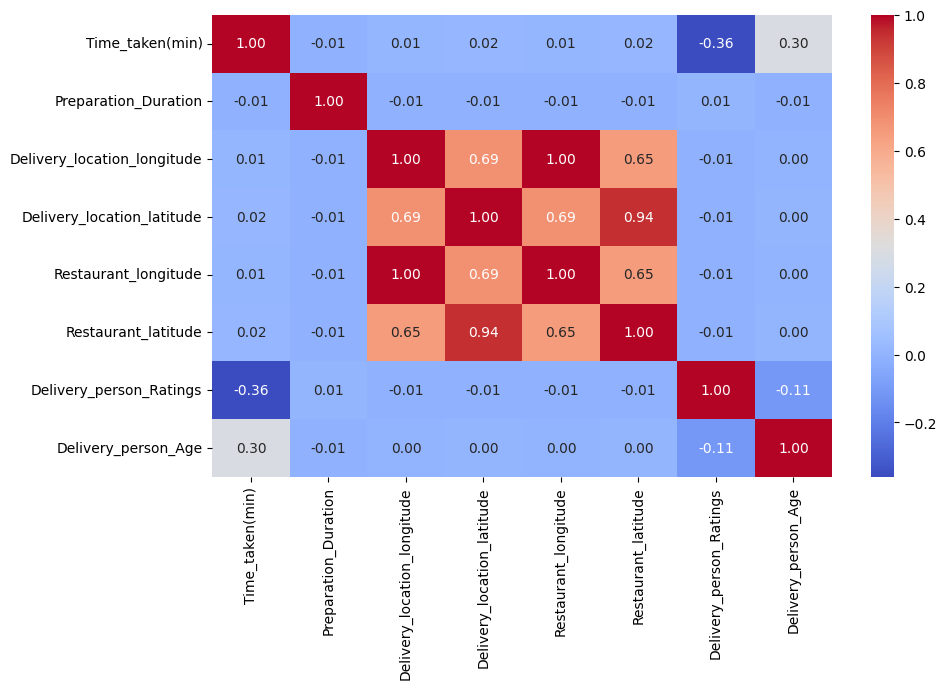

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(data[numerique].corr(), annot=True, fmt='.2f', cmap="coolwarm")
plt.show()
 

C:\Users\HP\AppData\Local\Temp\ipykernel_4128\2334318083.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data,y=n ,palette='Set2')


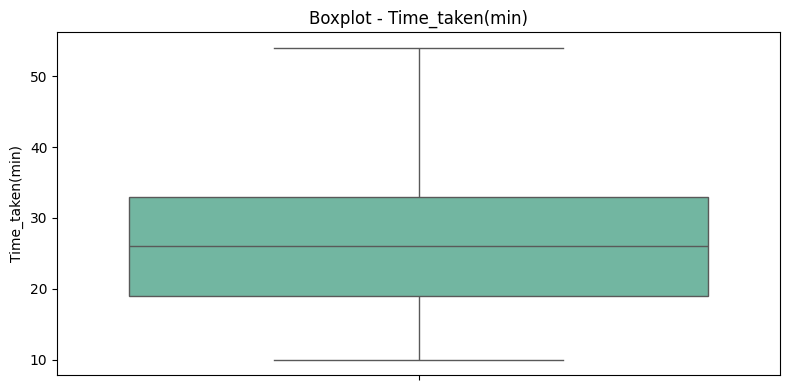

C:\Users\HP\AppData\Local\Temp\ipykernel_4128\2334318083.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data,y=n ,palette='Set2')


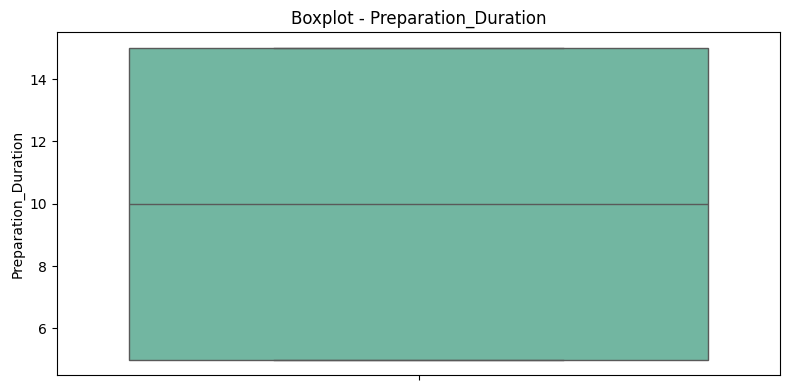

C:\Users\HP\AppData\Local\Temp\ipykernel_4128\2334318083.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data,y=n ,palette='Set2')


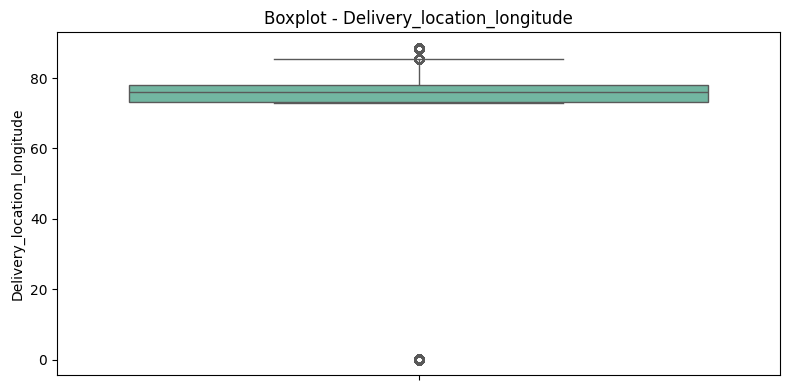

C:\Users\HP\AppData\Local\Temp\ipykernel_4128\2334318083.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data,y=n ,palette='Set2')


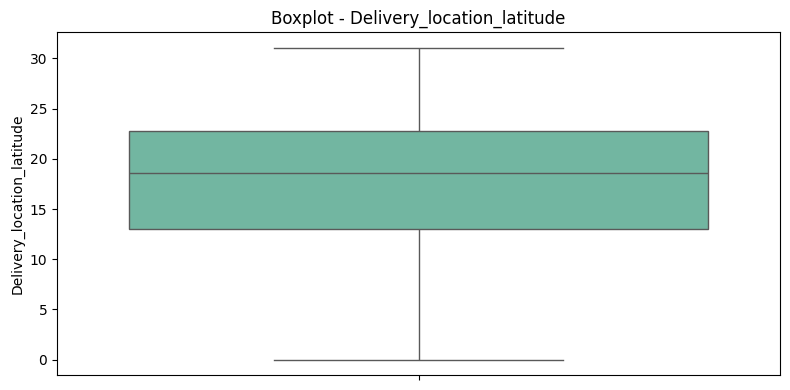

C:\Users\HP\AppData\Local\Temp\ipykernel_4128\2334318083.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data,y=n ,palette='Set2')


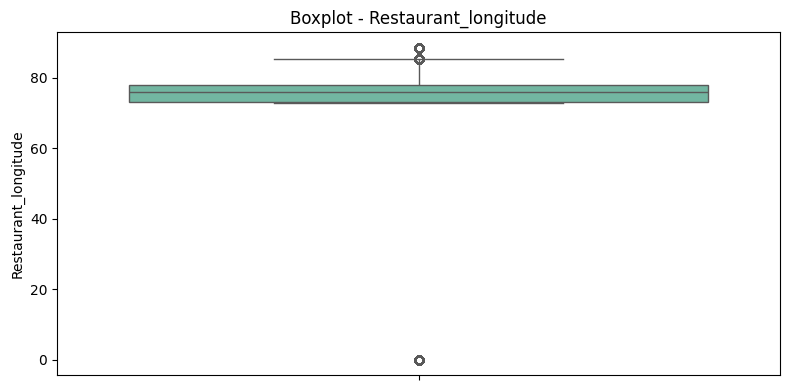

C:\Users\HP\AppData\Local\Temp\ipykernel_4128\2334318083.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data,y=n ,palette='Set2')


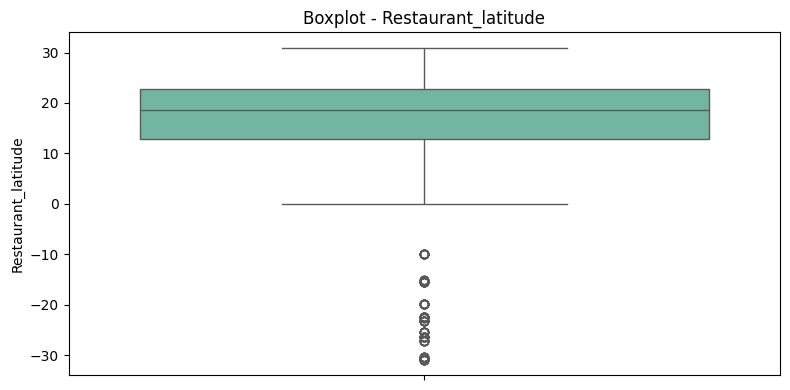

C:\Users\HP\AppData\Local\Temp\ipykernel_4128\2334318083.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data,y=n ,palette='Set2')


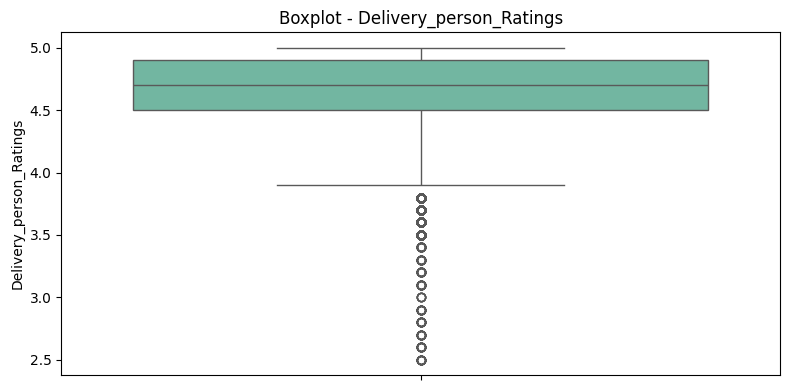

C:\Users\HP\AppData\Local\Temp\ipykernel_4128\2334318083.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data,y=n ,palette='Set2')


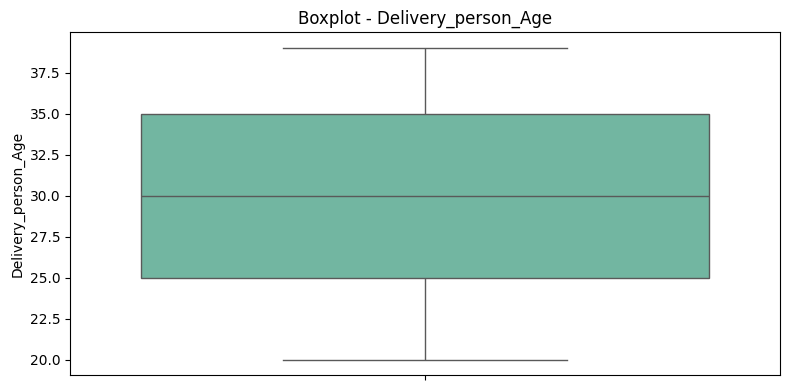

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

for n in numerique:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=data,y=n ,palette='Set2')
    plt.title(f'Boxplot - {n}')
    plt.tight_layout()
    plt.show()

In [ ]:
numeric_cals=["Preparation_Duration","Delivery_location_longitude","Delivery_location_latitude","Restaurant_longitude","Restaurant_latitude","Delivery_person_Ratings","Delivery_person_Age"]


In [56]:
data.to_csv("clean_data2.csv", index=False)

In [52]:
import pandas as pd 

data=pd.read_csv('./clean_data.csv')
data.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Weatherconditions_conditions Sandstorms,Weatherconditions_conditions Stormy,Weatherconditions_conditions Sunny,Weatherconditions_conditions Windy,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,Festival_No,Festival_Yes,Festival_nan
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,1900-01-01 11:30:00,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,1900-01-01 19:45:00,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,1900-01-01 08:30:00,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,1900-01-01 18:00:00,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,1900-01-01 13:30:00,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [53]:
from sklearn.model_selection import train_test_split



to_drop=["source","City","Type_of_order","Order_Date","Time_Order_picked","Time_Orderd","ID","Delivery_person_ID"]

X=data.drop(columns=["source","City","Type_of_order","Order_Date","Time_Order_picked","Time_Orderd","ID","Delivery_person_ID","Time_taken(min)"])
y=data["Time_taken(min)"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_cols=["Preparation_Duration","Delivery_location_longitude","Delivery_location_latitude","Restaurant_longitude","Restaurant_latitude","Delivery_person_Ratings","Delivery_person_Age"]
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [57]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model_lr = LinearRegression()

model_lr.fit(X_train, y_train)
y_pred = model_lr.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 5.574320439351987
RMSE: 6.989743526187483
R2 Score: 0.44327376786941775


In [58]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R2:", r2_score(y_test, y_pred_rf))

MAE: 4.682376440254613
R2: 0.5921526018227348


In [59]:
from sklearn.ensemble import GradientBoostingRegressor

model_gbr = GradientBoostingRegressor()
model_gbr.fit(X_train, y_train)
y_pred_gbr = model_gbr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_gbr))
print("R2:", r2_score(y_test, y_pred_gbr))

MAE: 4.6663798632827325
R2: 0.6027658582292437


In [60]:
from sklearn.linear_model import Ridge

model_rdg = Ridge(alpha=1.0)
model_rdg.fit(X_train, y_train)
y_pred_rdg = model_rdg.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_rdg))
print("R2:", r2_score(y_test, y_pred_rdg))

MAE: 5.909447952934594
R2: 0.3705791008141387


In [61]:
from sklearn.linear_model import Lasso

model_lss = Lasso(alpha=0.1)
model_lss.fit(X_train, y_train)
y_pred_lss = model_lss.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_lss))
print("R2:", r2_score(y_test, y_pred_lss))

MAE: 5.951457984076999
R2: 0.3625210269376863


In [63]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6
)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 4.530830383300781
R2: 0.6254121661186218


In [64]:
import joblib

joblib.dump(xgb, "delivery_model.pkl")

['delivery_model.pkl']

In [ ]:
import pandas as pd 
data=pd.read_csv('./clean_data2.csv')


0        21.0
1        21.0
2        21.0
3        21.0
4        21.0
         ... 
56936    21.0
56937    21.0
56938    21.0
56939    21.0
56940    21.0
Name: Delivery_Time, Length: 56941, dtype: float64

In [2]:
data['Delivery_Time'].value_counts()

Delivery_Time
21.0    56941
Name: count, dtype: int64